In [30]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import cartopy.crs as ccrs
import geopandas as gpd
import rioxarray
import cartopy.feature as cf
from rasterio.enums import Resampling


In [2]:
# load SEASONAL observed flow data
seasonal_flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
seasonal_flow_df.date = pd.to_datetime(seasonal_flow_df.date)
seasonal_flow_df.set_index('date', inplace=True)
seasonal_flow_df = seasonal_flow_df['1969':'2019'] 

# load metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
subset_meta = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()
meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),crs='EPSG:4326')

In [ ]:
seasonal_flow_df.columns

In [3]:
# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(seasonal_flow_df.columns)]
catchment_data.index = catchment_data['SITE']

In [118]:
def write_dataframe(direc,var,scen,number,s,seasonal_flow_df,catchment_data):
    ens_mem_season = xr.open_dataarray(direc+var+"/full/"+var+'_Amon_d4PDF_'+scen+'_m'+number+"_gaussian_"+s+'_1951-2021.nc')
            
    ens_mem_season = ens_mem_season.rio.write_crs("EPSG:4326")
    ens_mem_season = ens_mem_season.transpose('time','lat','lon')
    ens_mem_season = ens_mem_season.rio.set_spatial_dims('lon','lat')

    mem_interp = ens_mem_season.rio.reproject(ens_mem_season.rio.crs,shape=(150,150),resampling=Resampling.bilinear)

    df_dict = {'time':ens_mem_season.time.values}

    for site in seasonal_flow_df.columns:
        try:
            catchment_geo = catchment_data.loc[[float(site)]]
            model_catchment = ex_interp.rio.clip(catchment_geo.geometry,catchment_data.crs,all_touched=True)

            df_dict[site] = model_catchment.mean(['x','y']).values

        except KeyError as e:
            continue
                    
    df = pd.DataFrame(df_dict)
    
    return(df)

In [ ]:
var = 'ROF'
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'

for scen in ['HPB','HPB_NAT']:

    print(scen)

    for s in ['winter','spring','summer','autumn']:
        print(s)

        for ens_mem in range(1,101):
            print(ens_mem)
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            df = write_dataframe(direc,var,scen,number,s,seasonal_flow_df,catchment_data)
            
            df.to_csv(direc+var+"/full/catchment_resolution/"+var+'_d4PDF_'+scen+'_m'+number+"_gaussian_"+s+'_1951-2021.nc')


HPB
winter
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


In [100]:
print(ex.shape)
print(ex_interp.shape)

(71, 26, 27)
(71, 150, 150)


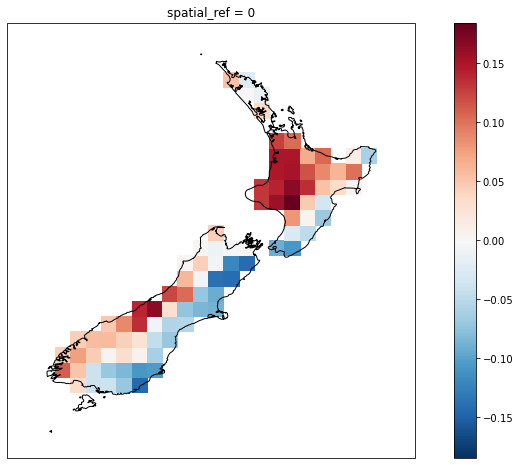

In [101]:
fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

ex.mean('time').plot(ax=axs)
axs.coastlines()
axs.add_feature(cf.BORDERS)
axs.set_extent([165,180, -49,-33])#, crs=noproj)

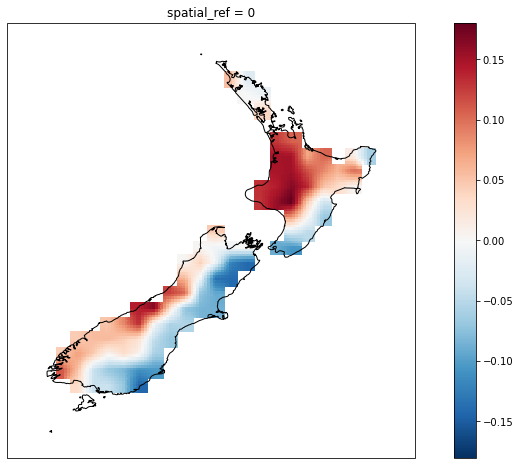

In [102]:
fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

ex_interp.mean('time').plot(ax=axs)
axs.coastlines()
axs.add_feature(cf.BORDERS)
axs.set_extent([165,180, -49,-33])#, crs=noproj)

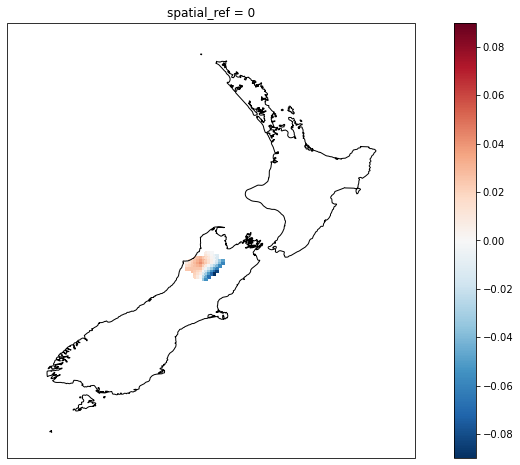

In [113]:
fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

model_catchment.mean('time').plot(ax=axs)
axs.coastlines()
axs.add_feature(cf.BORDERS)
#axs.add_feature(cf.STATES)
axs.set_extent([165,180, -49,-33])#, crs=noproj)

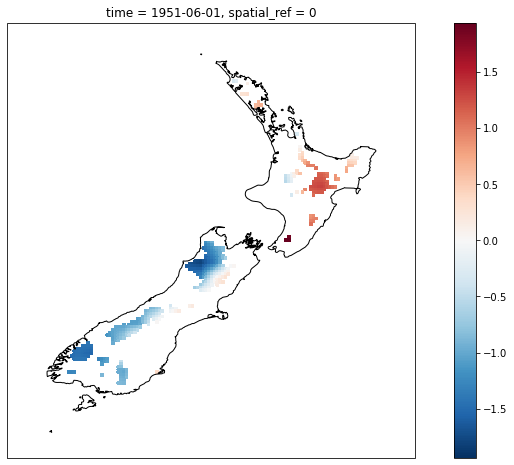

In [105]:
all_catchments = ex_interp.rio.clip(catchment_data.geometry.values)

fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

all_catchments.isel(time=0).plot(ax=axs)
axs.coastlines()
axs.add_feature(cf.BORDERS)
#axs.add_feature(cf.STATES)
axs.set_extent([165,180, -49,-33])#, crs=noproj)
